# HH special-case (BP) rule: how often is it applied, and why?

`precision_HH` computes two candidate upper limits and reports whichever is larger:

- **main rule**: `ULE_main = EE + SE_main`, where `SE_main = z_score * sr * BVs / sqrt(ns)` and `sr = std(E/BV)` over the *whole* non-certainty sample -- this is the standard variance-based Hansen-Hurwitz precision, and it depends directly on the errors actually observed in the sample.
- **special-case rule**: `ULE_spec = EEe + BP_binomial`, where `BP_binomial = SI * ns * Beta⁻¹(cl; 1, ns)` is the Binomial Stringer bound's own basic-precision (zero-error) term. This does **not** depend on the observed taints at all -- only on `SI`, `ns`, and `cl`. It's a fixed floor: the precision a Stringer-type bound would require even if nothing at all had been found.

`ULE = max(ULE_main, ULE_spec)`. Because `SE_main` is the *only* one of the two that reacts to what was actually observed, whether the special case wins comes down to whether the observed-variability estimate is large enough to clear the fixed floor -- and with very few errors in a sample (most values are 0), `sr` can end up small purely because there isn't much data to estimate a spread from, regardless of how large or small the one or two real taints happen to be.

**Part 1** walks through four concrete, labeled cases (0 errors, few errors with the rule applied, few errors with it not applied, and more errors with it not applied) with every component of both formulas shown side by side, so you can see *why* one wins in each case.

**Part 2** repeats the earlier zero-error/conditional-rate split, but now across the full `BV_pop x f_target x corr_target x r_target` grid using the real simulation output (all 10,000 iterations per cell, not a redrawn sample), matching the scope of `main_simulation_results.xlsx` and `bp_usage_data.xlsx`.

No conclusions are asserted — read the tables/plots and draw your own.

In [15]:
import sys
sys.path.insert(0, "..")

import re
import os
import glob

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from tqdm import tqdm

from create_population.import_population import import_population
from simulation.sample import Sample

pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 10 else f"{x:,.0f}")
CL = 0.80  # confidence level used throughout Part 1

## Part 1 — Four labeled cases, every component shown

One real population (`BV_15pct_above_SI`, `f_target=0.05`, `corr_target=0.25`, `r_target=0.01`), sample size 30. The cell below searches random draws until it finds:

1. a sample with **0 errors** (the rule always wins here -- `sr` is exactly 0, so `SE_main=0`),
2. a sample with **1-2 errors where the rule is applied**,
3. a sample with **1-2 errors where the rule is *not* applied**, for direct contrast, and
4. a sample with **3+ errors where the rule is not applied** (the more "typical" expectation).

In [16]:
z_score = norm.ppf(CL)

In [17]:
def draw_hh_sample(pop, N, BV, EE_true, sample_size, random_state):
    s = Sample(
        population=pop, N=N, EE=EE_true, BV=BV, sample_size=sample_size, cl=CL, z_score=z_score,
        hv_selection="iterative", selection_type="systematic_sampling",
        bound_estimator="HH", random_state=random_state,
    )
    s.run()
    return s


def decomposed_report(sample_obj, cl=CL):
    """Every component of both candidate ULEs for one already-drawn HH sample."""
    sample_s = sample_obj.sample_s
    ns = len(sample_s)
    BVs, SI, z_score = sample_obj.BVs, sample_obj.SI, sample_obj.z_score
    EE, EEe = sample_obj.EE_pred, sample_obj.EEe

    sr = np.std(sample_s["E"] / sample_s["BV"], ddof=1)
    SE_main = z_score * sr * BVs / np.sqrt(ns)

    reliability_factor = ns * beta_dist.ppf(q=cl, a=1, b=ns)
    BP_binom = SI * reliability_factor

    ULE_main = EE + SE_main
    ULE_spec = EEe + BP_binom
    rule_applied = ULE_spec > ULE_main

    return {
        "number_errors": sample_obj.number_errors,
        "ns": ns,
        "EE_pred": EE,
        "EEe (certainty stratum error)": EEe,
        "sr = std(E/BV)": sr,
        "z_score": z_score,
        "BVs": BVs,
        "SE_main = z*sr*BVs/sqrt(ns)": SE_main,
        "SI": SI,
        "cl": cl,
        "reliability_factor = ns*Beta^-1(cl,1,ns)": reliability_factor,
        "BP_binom = SI*reliability_factor": BP_binom,
        "ULE_main (= EE + SE_main)": ULE_main,
        "ULE_spec (= EEe + BP_binom)": ULE_spec,
        "rule_applied (spec > main)": rule_applied,
        "SE reported by precision_HH": sample_obj.SE,
    }

In [31]:
pop = import_population(BV_pop="BV_15pct_above_SI", f_target=0.05, corr_target=0.25, r_target=0.01)
BV, N, EE_true = pop["BV"].sum(), len(pop), pop["E"].sum()
SAMPLE_SIZE_PART1 = 100

zero_err = few_err_applied = few_err_not_applied = many_err_not_applied = None
for rs in range(50_000):
    s = draw_hh_sample(pop, N, BV, EE_true, sample_size=SAMPLE_SIZE_PART1, random_state=rs)
    applied = not np.isclose(s.ULE_HH, s.ULE)
    if s.number_errors == 0 and zero_err is None:
        zero_err = s
    elif 0 < s.number_errors <= 2 and applied and few_err_applied is None:
        few_err_applied = s
    elif 0 < s.number_errors <= 2 and not applied and few_err_not_applied is None:
        few_err_not_applied = s
    elif s.number_errors >= 3 and not applied and many_err_not_applied is None:
        many_err_not_applied = s
    if all(x is not None for x in [zero_err, few_err_applied, few_err_not_applied, many_err_not_applied]):
        break

cases = {
    "0 errors": zero_err,
    "1-2 errors, rule applied": few_err_applied,
    "1-2 errors, rule NOT applied": few_err_not_applied,
    "3+ errors, rule NOT applied": many_err_not_applied,
}
missing = [label for label, s in cases.items() if s is None]
if missing:
    print(f"Could not find an example for: {missing} within the search budget -- increase the range above if you need it.")

part1 = pd.DataFrame({label: decomposed_report(s) for label, s in cases.items() if s is not None})
part1

Could not find an example for: ['1-2 errors, rule applied'] within the search budget -- increase the range above if you need it.


,0 errors,"1-2 errors, rule NOT applied","3+ errors, rule NOT applied"
number_errors,0,1,3
ns,92,92,92
EE_pred,"2,132,708","33,756,227","97,003,264"
EEe (certainty stratum error),"2,132,708","2,132,708","2,132,708"
sr = std(E/BV),0.0000,0.1043,0.1786
z_score,0.8416,0.8416,0.8416
BVs,"2,909,363,702","2,909,363,702","2,909,363,702"
SE_main = z*sr*BVs/sqrt(ns),0.0000,"26,615,025","45,589,183"
SI,"31,623,518","31,623,518","31,623,518"
cl,0.8000,0.8000,0.8000


### Reading Part 1

Compare `sr = std(E/BV)` and the resulting `SE_main` across the columns: in the "1-2 errors" columns, `sr` is computed from a sample that's almost entirely zeros with one or two nonzero values, so it can come out small (or not) almost independently of `ns` — while `BP_binom` in the same rows is identical regardless of what those one or two values actually were, since it never looks at the taints at all. The "3+ errors" column is there so you can see a case with more observed variability comfortably clearing the fixed floor, for contrast.

## Part 3 -- Generalizing k: what if the special case applied beyond k=0?

`precision_HH`'s current code (in `src`) only ever uses the special-case (`ULE_spec`) rule when `sr == 0`, i.e. exactly when `number_errors == 0` -- in other words, k=0. This section asks: what would happen to **coverage** and to the **rule's usage rate** if that threshold were relaxed to k=1, 2, or 3 ("use `ULE_spec` whenever `number_errors <= k`")?

**Nothing in `src` is touched.** `ULE_main` is read directly off the real `Sample` object (`sample_obj.ULE_HH`, which `precision_HH` always returns as its second value regardless of which rule wins). `ULE_spec` is recomputed locally below, using the exact same formula `precision_HH` itself uses (`EEe + SI * ns * Beta^-1(cl, 1, ns)`) -- it just isn't gated by `sr==0` here, so both candidate values are available for every draw and any k-threshold can be applied afterward.

This needs fresh samples (not the exported `results_*.xlsx` files, which only ever recorded the k=0 outcome) -- everything below redraws directly through the real `Sample` pipeline.

In [19]:
TE_PERC = 0.02


def ule_spec(sample_obj, cl=CL):
    """Same formula precision_HH uses for its special-case ULE, computed independently
    of the sr==0 gate so it's available regardless of which rule src actually picked."""
    ns = len(sample_obj.sample_s)
    reliability_factor = ns * beta_dist.ppf(q=cl, a=1, b=ns)
    BP_binom = sample_obj.SI * reliability_factor
    return sample_obj.EEe + BP_binom

def ule_main(sample_obj, z_score=z_score):
    """Same formula precision_HH uses for its special-case ULE, computed independently
    of the sr==0 gate so it's available regardless of which rule src actually picked."""
    sr = np.std(sample_obj.sample_s['ER'], ddof=1) 
    SE_main = z_score * sr * sample_obj.BVs * np.sqrt((sample_obj.BVs-sample_obj.sample_s['BV'].sum())/sample_obj.BVs) / np.sqrt(sample_obj.ns)
    ULE_main = sample_obj.EE_pred + SE_main
    return ULE_main

def draw_components(pop, N, BV, EE_true, sample_size, iterations, seed=0):
    """One row per draw: number_errors, and both candidate ULEs. k-thresholds are
    applied afterward from this cached data, so each combo is only drawn once."""
    rows = []
    for i in range(iterations):
        s = draw_hh_sample(pop, N, BV, EE_true, sample_size, random_state=seed + i)
        rows.append({
            "number_errors": s.number_errors,
            "ULE_main": ule_main(s),
            "ULE_spec": ule_spec(s),
        })
    return pd.DataFrame(rows)


def k_sweep(components_df, EE_true, TE, ks=(0, 1, 2, 3)):
    rows = []
    for k in ks:
        rule_used = components_df["number_errors"] <= k
        ULE_k = np.where(rule_used, components_df["ULE_spec"], components_df["ULE_main"])
        rows.append({
            "k": k,
            "rule_usage_rate": rule_used.mean(),
            "coverage": (ULE_k >= EE_true).mean(),
            "rate_of_acceptance": (ULE_k <= TE).mean(),
        })
    return pd.DataFrame(rows)


### One combo in detail

Same population as Part 1 (`BV_15pct_above_SI`, `f_target=0.05`, `corr_target=0.25`, `r_target=0.01`), sample size 30, 3,000 draws.

In [20]:
pop_k = import_population(BV_pop="BV_15pct_above_SI", f_target=0.05, corr_target=0.25, r_target=0.01)
BV_k, N_k, EE_true_k = pop_k["BV"].sum(), len(pop_k), pop_k["E"].sum()
TE_k = TE_PERC * BV_k

components_one = draw_components(pop_k, N_k, BV_k, EE_true_k, sample_size=30, iterations=3000)
k_sweep_one = k_sweep(components_one, EE_true_k, TE_k)
k_sweep_one

,k,rule_usage_rate,coverage,rate_of_acceptance
0,0,0.1063,0.3490,0.6510
1,1,0.7877,1.0000,0.0000
2,2,0.9720,1.0000,0.0000
3,3,0.9963,1.0000,0.0000


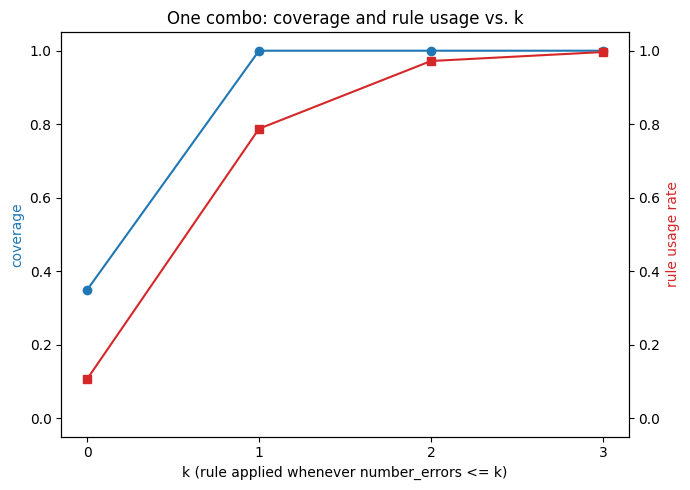

In [21]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

ax1.plot(k_sweep_one["k"], k_sweep_one["coverage"], marker="o", color="tab:blue", label="coverage")
ax1.set_ylabel("coverage", color="tab:blue")
ax1.set_ylim(-0.05, 1.05)

ax2.plot(k_sweep_one["k"], k_sweep_one["rule_usage_rate"], marker="s", color="tab:red", label="rule usage rate")
ax2.set_ylabel("rule usage rate", color="tab:red")
ax2.set_ylim(-0.05, 1.05)

ax1.set_xlabel("k (rule applied whenever number_errors <= k)")
ax1.set_xticks(k_sweep_one["k"])
plt.title("One combo: coverage and rule usage vs. k")
plt.tight_layout()
plt.show()

### Grid sweep: does this pattern hold generally?

Same idea across `f_target x r_target x sample_size` (one `BV_pop`/`corr_target`, matching the rest of this notebook), 1,500 draws per combo. Should comfortably finish in well under 30 minutes.

In [26]:
import itertools
import time

BV_POP_GRID = ["BV_5pct_above_SI", "BV_15pct_above_SI", "BV_30pct_above_SI"]
CORR_GRID = [0.10, 0.25, 0.50]
F_GRID = [0.05, 0.20, 0.50]
R_GRID = [0.002, 0.01, 0.03, 0.04]
SS_GRID = [30, 65, 100, 150, 200]
ITER_GRID = 1000

t0 = time.time()
grid_rows = []
combos = list(itertools.product(F_GRID, R_GRID, SS_GRID, BV_POP_GRID, CORR_GRID))
for f, r, ss, bv, corr in tqdm(combos):
    pop_g = import_population(BV_pop=bv, f_target=f, corr_target=corr, r_target=r)
    BV_g, N_g, EE_g = pop_g["BV"].sum(), len(pop_g), pop_g["E"].sum()
    TE_g = TE_PERC * BV_g

    comp = draw_components(pop_g, N_g, BV_g, EE_g, sample_size=ss, iterations=ITER_GRID)
    ks = k_sweep(comp, EE_g, TE_g)
    ks["f_target"] = f
    ks["r_target"] = r
    ks["bv_target"] = bv
    ks["corr_target"] = corr
    ks["sample_size"] = ss
    grid_rows.append(ks)

k_grid = pd.concat(grid_rows, ignore_index=True)
print(f"done in {time.time() - t0:.0f}s")


100%|██████████| 540/540 [19:03<00:00,  2.12s/it]

done in 1143s


In [27]:
k_grid.to_excel("../results/hh_k_threshold_grid.xlsx", index=False)
k_grid

,k,rule_usage_rate,coverage,rate_of_acceptance,f_target,r_target,bv_target,corr_target,sample_size
0,0,0.1460,0.2250,0.7750,0.0500,0.0020,BV_5pct_above_SI,0.1000,30
1,1,0.9310,1.0000,0.0000,0.0500,0.0020,BV_5pct_above_SI,0.1000,30
2,2,1.0000,1.0000,0.0000,0.0500,0.0020,BV_5pct_above_SI,0.1000,30
3,3,1.0000,1.0000,0.0000,0.0500,0.0020,BV_5pct_above_SI,0.1000,30
4,0,0.1460,0.2130,0.7870,0.0500,0.0020,BV_5pct_above_SI,0.2500,30
...,...,...,...,...,...,...,...,...,...
2155,3,0.0000,0.7340,0.0000,0.5000,0.0400,BV_30pct_above_SI,0.2500,200
2156,0,0.0000,0.7470,0.0000,0.5000,0.0400,BV_30pct_above_SI,0.5000,200
2157,1,0.0000,0.7470,0.0000,0.5000,0.0400,BV_30pct_above_SI,0.5000,200
2158,2,0.0000,0.7470,0.0000,0.5000,0.0400,BV_30pct_above_SI,0.5000,200


### Coverage and rule-usage rate vs. k, by `f_target` and `r_target` (averaged over sample size)

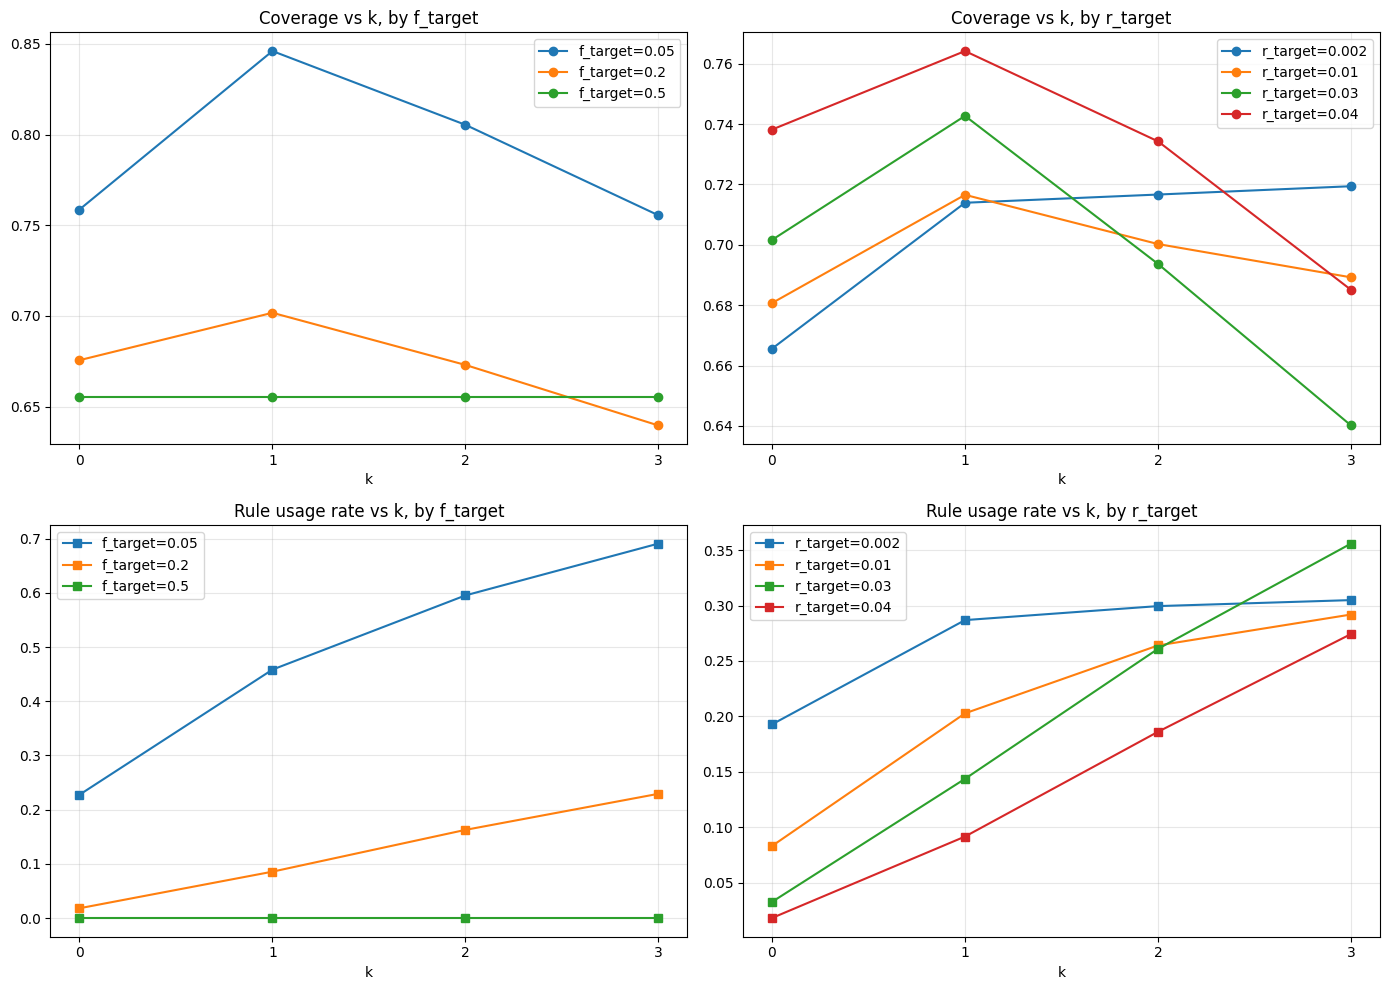

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for f, grp in k_grid.groupby("f_target"):
    m = grp.groupby("k")["coverage"].mean()
    axes[0, 0].plot(m.index, m.values, marker="o", label=f"f_target={f}")
axes[0, 0].set_title("Coverage vs k, by f_target")
axes[0, 0].legend()

for r, grp in k_grid.groupby("r_target"):
    m = grp.groupby("k")["coverage"].mean()
    axes[0, 1].plot(m.index, m.values, marker="o", label=f"r_target={r}")
axes[0, 1].set_title("Coverage vs k, by r_target")
axes[0, 1].legend()

for f, grp in k_grid.groupby("f_target"):
    m = grp.groupby("k")["rule_usage_rate"].mean()
    axes[1, 0].plot(m.index, m.values, marker="s", label=f"f_target={f}")
axes[1, 0].set_title("Rule usage rate vs k, by f_target")
axes[1, 0].legend()

for r, grp in k_grid.groupby("r_target"):
    m = grp.groupby("k")["rule_usage_rate"].mean()
    axes[1, 1].plot(m.index, m.values, marker="s", label=f"r_target={r}")
axes[1, 1].set_title("Rule usage rate vs k, by r_target")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("k")
    ax.set_xticks([0, 1, 2, 3])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Same graph, by `sample_size` (averaged over f_target and r_target)

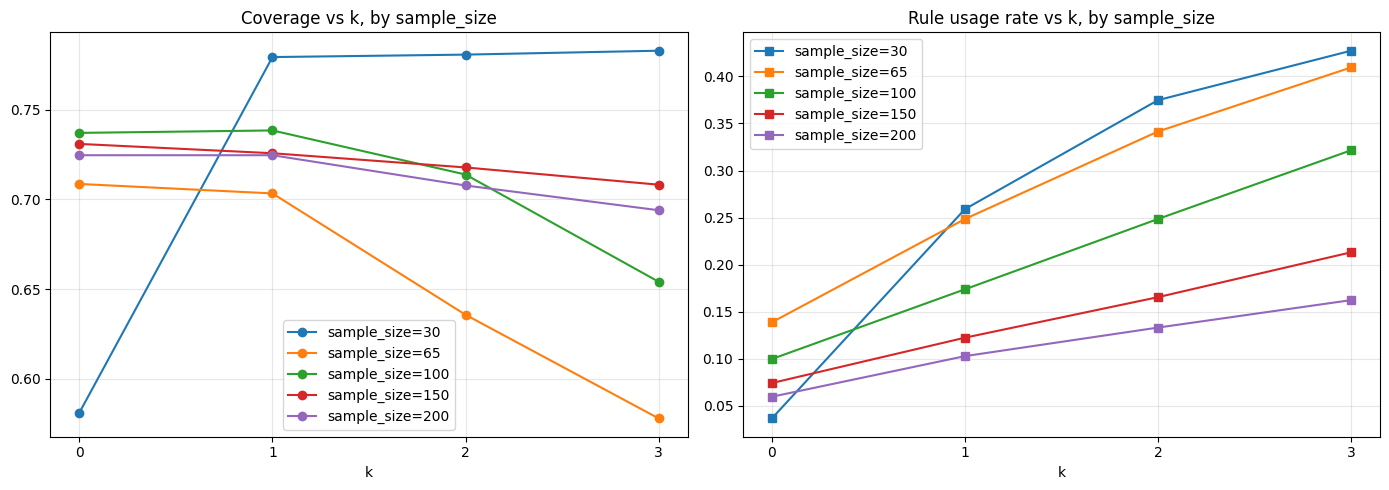

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ss, grp in k_grid.groupby("sample_size"):
    m = grp.groupby("k")["coverage"].mean()
    axes[0].plot(m.index, m.values, marker="o", label=f"sample_size={ss}")
axes[0].set_title("Coverage vs k, by sample_size")
axes[0].legend()

for ss, grp in k_grid.groupby("sample_size"):
    m = grp.groupby("k")["rule_usage_rate"].mean()
    axes[1].plot(m.index, m.values, marker="s", label=f"sample_size={ss}")
axes[1].set_title("Rule usage rate vs k, by sample_size")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("k")
    ax.set_xticks([0, 1, 2, 3])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Notes

- `k_grid` is also saved to `../results/hh_k_threshold_grid.xlsx` for pivoting on your own.
- `k=0` in every table/plot here is the *current* `src` behavior -- it should match (up to Monte Carlo noise, since this redraws fresh samples rather than reusing the exported files) the k=0 `Coverage` already reported for HH in `main_simulation_results.xlsx`.
- No summary verdict is given here on purpose -- read the table/plots and judge for yourself whether extending k trades away too much (the rule firing on genuinely evidenced samples too) for what it fixes in coverage.

## Part 4 -- Is ULE_main actually higher than ULE_spec? (separate from Part 3)

A standalone check, independent of Part 3's `k_grid`/`k_sweep` (nothing above is modified or
reused for its results): for samples with `number_errors <= k`, what fraction have
`ULE_main > ULE_spec` -- i.e. where forcing the special case at that k would have discarded an
already-larger `ULE_main`, rather than rescuing a genuinely too-small one. Draws its own fresh
samples via the same `draw_hh_sample` / `ule_main` / `ule_spec` helpers Part 3 defines, across
sample sizes in particular.

In [ ]:
def main_vs_spec_components(pop, N, BV, EE_true, sample_size, iterations, seed=0):
    """One row per draw: number_errors, ULE_main, ULE_spec. Independent of draw_components /
    k_grid above -- used only by this section."""
    rows = []
    for i in range(iterations):
        s = draw_hh_sample(pop, N, BV, EE_true, sample_size, random_state=seed + i)
        rows.append({
            "number_errors": s.number_errors,
            "ULE_main": ule_main(s),
            "ULE_spec": ule_spec(s),
        })
    return pd.DataFrame(rows)


def main_gt_spec_by_k(components_df, ks=(0, 1, 2, 3)):
    rows = []
    for k in ks:
        eligible = components_df[components_df["number_errors"] <= k]
        rate = (eligible["ULE_main"] > eligible["ULE_spec"]).mean() if len(eligible) else float("nan")
        rows.append({"k": k, "n_eligible": len(eligible), "main_gt_spec_rate": rate})
    return pd.DataFrame(rows)

In [101]:
import itertools
import time

BV_POP_GRID_P4 = ["BV_5pct_above_SI", "BV_15pct_above_SI", "BV_30pct_above_SI"]
CORR_GRID_P4 = [0.10, 0.25, 0.50]
F_GRID_P4 = [0.05, 0.20, 0.50]
R_GRID_P4 = [0.002, 0.01, 0.03, 0.04]
SS_GRID_P4 = [30, 65, 100, 150, 200]
ITER_GRID_P4 = 1000

t0 = time.time()
p4_rows = []
combos_p4 = list(itertools.product(F_GRID_P4, R_GRID_P4, SS_GRID_P4, BV_POP_GRID_P4, CORR_GRID_P4))
for f, r, ss, bv, corr in tqdm(combos_p4):
    pop_p4 = import_population(BV_pop=bv, f_target=f, corr_target=corr, r_target=r)
    BV_p4, N_p4, EE_p4 = pop_p4["BV"].sum(), len(pop_p4), pop_p4["E"].sum()

    comp_p4 = main_vs_spec_components(pop_p4, N_p4, BV_p4, EE_p4, sample_size=ss, iterations=ITER_GRID_P4)
    res = main_gt_spec_by_k(comp_p4)
    res["f_target"] = f
    res["r_target"] = r
    res["bv_target"] = bv
    res["corr_target"] = corr
    res["sample_size"] = ss
    p4_rows.append(res)

main_gt_spec_grid = pd.concat(p4_rows, ignore_index=True)
print(f"done in {time.time() - t0:.0f}s")
main_gt_spec_grid.to_excel("../results/main_gt_spec_grid.xlsx", index=False)
main_gt_spec_grid

done in 1356s
saved -> ../results/main_gt_spec_grid.xlsx


      k  n_eligible  ...  corr_target  sample_size
0     0         146  ...         0.10           30
1     1         931  ...         0.10           30
2     2        1000  ...         0.10           30
3     3        1000  ...         0.10           30
4     0         146  ...         0.25           30
...  ..         ...  ...          ...          ...
2155  3           0  ...         0.25          200
2156  0           0  ...         0.50          200
2157  1           0  ...         0.50          200
2158  2           0  ...         0.50          200
2159  3           0  ...         0.50          200

[2160 rows x 8 columns]

### `main_gt_spec_rate` by sample size and k

In [102]:
main_gt_spec_grid.groupby(["sample_size", "k"])["main_gt_spec_rate"].mean().unstack("k")

k              0         1         2         3
sample_size                                   
30           0.0  0.062714  0.255771  0.291457
65           0.0  0.191206  0.415651  0.448517
100          0.0  0.000000  0.418162  0.535486
150          0.0  0.000000  0.544951  0.649022
200          0.0  0.000000  0.582788  0.703656

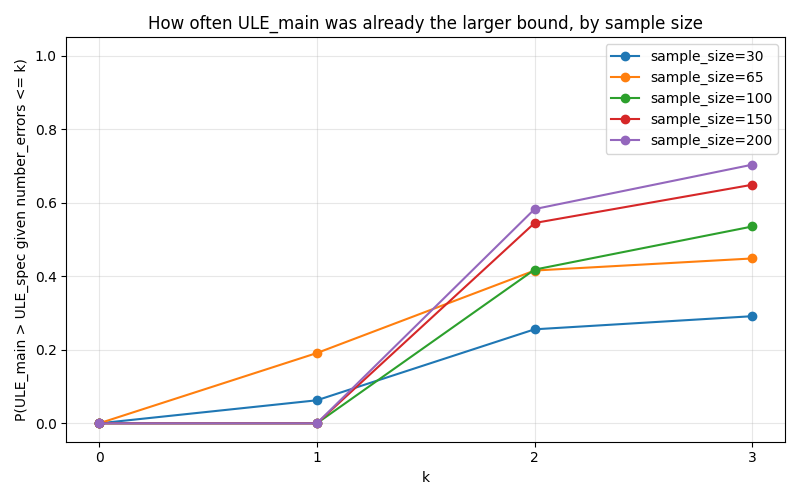

In [103]:
fig, ax = plt.subplots(figsize=(8, 5))
for ss, grp in main_gt_spec_grid.groupby("sample_size"):
    m = grp.groupby("k")["main_gt_spec_rate"].mean()
    ax.plot(m.index, m.values, marker="o", label=f"sample_size={ss}")
ax.set_xlabel("k")
ax.set_ylabel("P(ULE_main > ULE_spec given number_errors <= k)")
ax.set_title("How often ULE_main was already the larger bound, by sample size")
ax.set_xticks([0, 1, 2, 3])
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()